In [1]:
import os
import sys
import re
import tqdm
from pathlib import Path
from dotenv import load_dotenv
import supervision as sv
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

load_dotenv('.env')
DIR_SRC = os.getenv('DIR_SRC')
dir_s1 = Path("out") / "study1"
ls_meta = [f for f in dir_s1.iterdir() if f.suffix == '.csv' and f.name.startswith('results_')]
ls_meta

[PosixPath('out/study1/results_5.csv'),
 PosixPath('out/study1/results_3.csv'),
 PosixPath('out/study1/results_1.csv'),
 PosixPath('out/study1/results_6.csv'),
 PosixPath('out/study1/results_9.csv'),
 PosixPath('out/study1/results_0.csv'),
 PosixPath('out/study1/results_2.csv'),
 PosixPath('out/study1/results_4.csv'),
 PosixPath('out/study1/results_8.csv'),
 PosixPath('out/study1/results_7.csv')]

In [2]:
data = pd.read_csv(ls_meta[0])
for i in range(1, len(ls_meta)):
    data_tmp = pd.read_csv(ls_meta[i])
    data = pd.concat([data, data_tmp])
print(data.columns)
data
# study1: n (5) x split (6) x rep (20) = 600
# study2: model (5) x split (6) = 30
# total: 630

Index(['model', 'n_params', 'n_samples', 'thread', 'iters', 'split',
       'strategy', 'time_hptuning', 'time_inference', 'divider', 'overlap',
       'map5095', 'map50', 'precision', 'recall', 'f1', 'n_all', 'n_fn',
       'n_fp'],
      dtype='object')


,model,n_params,n_samples,thread,iters,split,strategy,time_hptuning,time_inference,divider,overlap,map5095,map50,precision,recall,f1,n_all,n_fn,n_fp
0,yolo11n,2.6,64,5,1,test_a01,baseline,0.00,8.62,0.0,0.00,0.3526,0.8842,0.9018,0.8743,0.8878,1734,218,165
1,yolo11n,2.6,64,5,1,test_a01,bo_exploration,7.62,98.25,3.0,0.35,0.3276,0.8486,0.8382,0.8454,0.8418,1734,268,283
2,yolo11n,2.6,64,5,1,test_a01,bo_exploitation,7.21,61.48,2.0,0.21,0.3340,0.8614,0.8620,0.8679,0.8649,1734,229,241
3,yolo11n,2.6,64,5,1,test_a01,grid_search,16.39,95.09,4.0,0.25,0.3067,0.8197,0.7708,0.8397,0.8038,1734,278,433
4,yolo11n,2.6,64,5,1,test_a02,baseline,0.00,6.49,0.0,0.00,0.2080,0.6530,0.7222,0.6880,0.7047,1266,395,335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
819,rtdetr-l,45.0,256,7,2,test_b03,bo_exploitation,24.42,123.39,3.0,0.38,0.1246,0.3932,0.2265,0.4895,0.3097,143,73,239
820,rtdetr-l,45.0,256,7,2,test_b03,grid_search,35.88,257.56,4.0,0.50,0.0431,0.1282,0.0453,0.7552,0.0854,143,35,2278
821,rtdetr-l,45.0,1024,7,2,test_a01,baseline,0.00,12.37,0.0,0.00,0.4149,0.9546,0.9394,0.9296,0.9345,1734,122,104
822,rtdetr-l,45.0,1024,7,2,test_a01,bo_exploration,17.46,112.67,2.0,0.37,0.3808,0.9381,0.8943,0.9469,0.9199,1734,92,194


In [3]:
# calculate mean, median, std, min, max
data_sum = data.groupby(['model', 'n_samples', 'split', "strategy"]).agg(
    pre_mean=pd.NamedAgg(column='precision', aggfunc='mean'),
    pre_median=pd.NamedAgg(column='precision', aggfunc='median'),
    pre_std=pd.NamedAgg(column='precision', aggfunc='std'),
    pre_min=pd.NamedAgg(column='precision', aggfunc='min'),
    pre_max=pd.NamedAgg(column='precision', aggfunc='max'),
    rec_mean=pd.NamedAgg(column='recall', aggfunc='mean'),
    rec_median=pd.NamedAgg(column='recall', aggfunc='median'),
    rec_std=pd.NamedAgg(column='recall', aggfunc='std'),
    rec_min=pd.NamedAgg(column='recall', aggfunc='min'),
    rec_max=pd.NamedAgg(column='recall', aggfunc='max'),
    n_obs=pd.NamedAgg(column='precision', aggfunc='count'),
).reset_index()
data_sum

,model,n_samples,split,strategy,pre_mean,pre_median,pre_std,pre_min,pre_max,rec_mean,rec_median,rec_std,rec_min,rec_max,n_obs
0,rtdetr-l,64,test_a01,baseline,0.895425,0.89230,0.015751,0.8613,0.9254,0.878195,0.88350,0.015678,0.8443,0.9037,20
1,rtdetr-l,64,test_a01,bo_exploitation,0.866665,0.87640,0.041520,0.7824,0.9117,0.875145,0.87195,0.025766,0.7976,0.9118,20
2,rtdetr-l,64,test_a01,bo_exploration,0.862430,0.87450,0.042724,0.7756,0.9191,0.868045,0.87225,0.028236,0.8131,0.9118,20
3,rtdetr-l,64,test_a01,grid_search,0.857350,0.86125,0.045907,0.7813,0.9266,0.831755,0.84920,0.056745,0.6448,0.8910,20
4,rtdetr-l,64,test_a02,baseline,0.806170,0.82425,0.063638,0.6481,0.8808,0.787830,0.80650,0.044594,0.7148,0.8586,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,yolo11n,1024,test_b02,grid_search,0.745770,0.74425,0.068940,0.6224,0.8900,0.724298,0.72780,0.050002,0.6020,0.8207,50
212,yolo11n,1024,test_b03,baseline,0.764370,0.78940,0.146189,0.3136,0.9655,0.500698,0.49650,0.071329,0.3287,0.6853,50
213,yolo11n,1024,test_b03,bo_exploitation,0.524362,0.51220,0.149373,0.2702,0.8421,0.570066,0.56640,0.109409,0.3287,0.7762,50
214,yolo11n,1024,test_b03,bo_exploration,0.536110,0.53570,0.150635,0.2212,0.8492,0.527412,0.54545,0.101043,0.3077,0.7483,50


In [4]:
data_sum.to_csv(Path("out") / "study1_pivot.csv", index=False)

In [19]:
data_fig = data.melt(id_vars=["model", "n_samples", "split", "strategy"], 
                     var_name="metric", value_name="score")
data_fig = data_fig.query("metric in ['precision', 'recall', 'f1']")
data_fig["similar"] = data_fig["split"].apply(lambda x: "a" in x)
data_fig

,model,n_samples,split,strategy,metric,score,similar
74997,yolo11n,64,test_a01,baseline,precision,0.9018,True
74998,yolo11n,64,test_a01,bo_exploration,precision,0.8382,True
74999,yolo11n,64,test_a01,bo_exploitation,precision,0.8620,True
75000,yolo11n,64,test_a01,grid_search,precision,0.7708,True
75001,yolo11n,64,test_a02,baseline,precision,0.7222,True
...,...,...,...,...,...,...,...
99991,rtdetr-l,256,test_b03,bo_exploitation,f1,0.3097,False
99992,rtdetr-l,256,test_b03,grid_search,f1,0.0854,False
99993,rtdetr-l,1024,test_a01,baseline,f1,0.9345,True
99994,rtdetr-l,1024,test_a01,bo_exploration,f1,0.9199,True


## Study 1

In [31]:
# anova:  f1 ~ model + n_samples + split + strategy
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
model = ols('score ~ C(model) + C(strategy) + C(model):C(strategy)', data=data_fig.query("metric == 'f1' and strategy in ['baseline', 'grid_search']")).fit()
# t-test each slope : f1 ~ model + n_samples + split + strategy
print(model.summary())
print(anova_lm(model, typ=2))

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     42.40
Date:                Fri, 30 May 2025   Prob (F-statistic):           9.66e-43
Time:                        22:45:54   Log-Likelihood:                 1395.5
No. Observations:                4164   AIC:                            -2779.
Df Residuals:                    4158   BIC:                            -2741.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

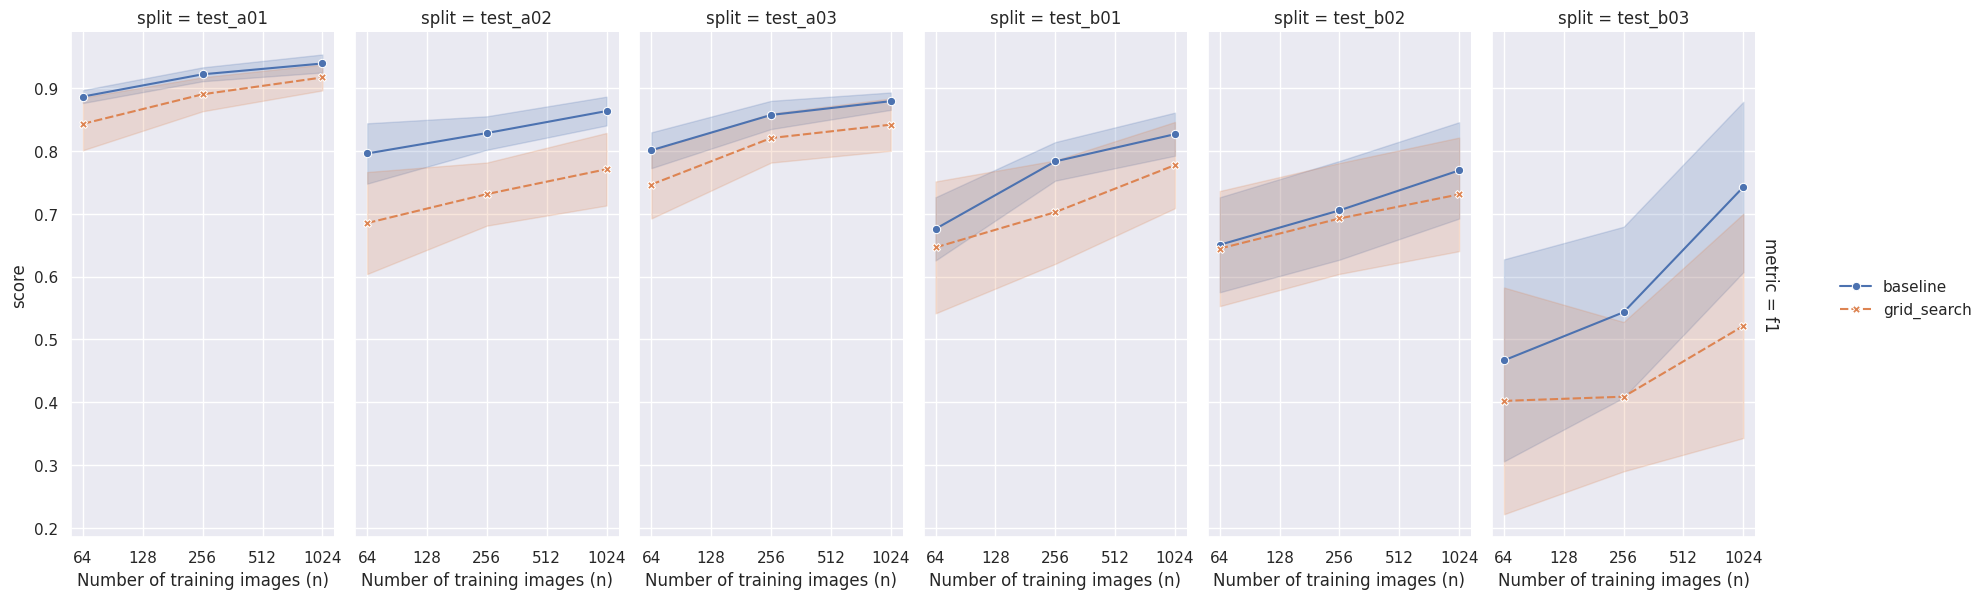

In [33]:
sns.set("notebook")
splits_s1 = [
    "test_a01", "test_a02", "test_a03",
    "test_b01", "test_b02", "test_b03",
            ]
strategy_order = ["baseline", 
                  "grid_search", 
                #   "bo_exploration", 
                #   "bo_exploitation",
                  ]
model_order = ["yolo11n", "yolo11m", "rtdetr-l"]
g = sns.FacetGrid(
    data_fig.query(f"split in {splits_s1} and metric in ['f1'] and model == 'rtdetr-l'"),
    row="metric", col="split",
    margin_titles=True,
    sharey=True,
)
g.map_dataframe(sns.lineplot, 
    x="n_samples", y="score", 
    # hue="model", style="strategy",
    # hue_order=model_order,
    # style_order=strategy_order,
    hue="strategy", style="strategy",
    hue_order=strategy_order,
    style_order=strategy_order,
    err_style="band", errorbar=("sd", 1),
    markers=True,
    # palette=["Grey", "#FF1F5B", "#00B000", "#009ADE", "#AF58BA"],
)
# title
# g.figure.suptitle("Model Generalization in each Data Configuration")
g.set(
    xscale="log",
    xticks=[2**i for i in range(6, 11)],
    xticklabels=[2**i for i in range(6, 11)],
    xlabel="Number of training images (n)",)
g.figure.subplots_adjust(right=1.2)
g.add_legend()
g.figure.set_size_inches(20, 8)
g.savefig(Path("out") / "results_study1.png", dpi=300)
